# NWS watch, warning, and advisory geometries

Every National Weather Service watch, warning, and advisory carries a VTEC
code: a phenomenon (`TO` tornado, `SV` severe thunderstorm), a significance
(`W` warning, `A` watch, `Y` advisory), an issuing office, and an event
number. Since 2007 a tornado or severe thunderstorm warning is drawn as a
polygon around the threat; watches and most other products are still issued
for whole counties or forecast zones. The Iowa Environmental Mesonet (IEM) at
Iowa State University archives the NWS product stream and serves every
product with its geometry, for any window, as a zipped shapefile; the NWS's
own API keeps no archive.

This walkthrough pulls the tornado warnings and watches issued for Oklahoma
on the evening of 6 May 2024 and maps them. It needs matplotlib, pandas, and
pyshp, which reads shapefiles, since usdata has no shapefile reader; the
file is under a megabyte and the run takes a few seconds.

In [1]:
import zipfile
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import shapefile
from matplotlib.patches import PathPatch
from matplotlib.path import Path as Outline

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}; pyshp {shapefile.__version__}")

Executed (UTC): 2026-10-08T23:57:26+00:00
usdata 0.34.0; pandas 3.0.6; pyshp 3.1.6


## Select

The manifest names a state, a window, and two event types. `location:
Oklahoma` becomes IEM's state filter; a county is refused, since the service
filters by state or issuing office (`params: {wfo: OUN}`), not by county. The
window selects rows by `ISSUED`, the event's start, inclusive at both ends:
from 18 UTC on 6 May (1 PM CDT) to 12 UTC the next morning. `events` names
VTEC phenomenon and significance pairs; without it every product comes back,
heat and flood and winter advisories included.

In [2]:
print(manifest.read_text())

name: oklahoma-tornado-warnings-may-2024
sources:
  - name: oklahoma
    dataset: noaa:nws-warnings
    # A state, not a county: the service filters by state or issuing office.
    location: Oklahoma
    # Selected by ISSUED, the event's start, in UTC: 1 PM CDT on 6 May to 7 AM the next day.
    start: 2024-05-06T18:00Z
    end: 2024-05-07T12:00Z
    params: {events: "TO.W,TO.A"}



## What arrives

One zip per UTC month the window touches, so one here. Inside are the
shapefile's parts and a CSV of the same attributes. IEM builds the zip on
request and stamps it with the time, so two identical requests return
different bytes; usdata rewrites it in a canonical form, the same members
stored uncompressed with fixed stamps, and records that in the provenance.
That is what lets the lockfile written beside the manifest pin it.

In [3]:
result = pull(manifest)
item = result.one("oklahoma")
print("File:", item.path.name)
print(f"Bytes: {item.provenance.size:,}")
print("Source:", item.provenance.source_url)
print("Checksum:", item.provenance.checksum)
print("Transformations:", *item.provenance.transformations, sep="\n  ")
with zipfile.ZipFile(item.path) as archive:
    for info in archive.infolist():
        print(f"  {info.filename:42} {info.file_size:>9,} bytes")

File: wwa_20240506_20240507_cbe2ee89a613d926d180.zip
Bytes: 326,270
Source: https://mesonet.agron.iastate.edu/cgi-bin/request/gis/watchwarn.py?accept=shapefile&location_group=states&states=OK&limitps=1&phenomena=TO%2CTO&significance=W%2CA&sts=2024-05-06T18%3A00%3A00Z&ets=2024-05-07T12%3A00%3A01Z
Checksum: sha256:20535ffc9408817303aa7bcb80d0d44d03331fd0f6858d57f9167b7d6f91a91b
Transformations:
  iem canonical zip: members kept in order, stored uncompressed with timestamps fixed at 1980-01-01 00:00 and no extra fields; the DBF header's last-update date set to 1980-01-01
  wwa_202405061800_202405071200.shp            239,364 bytes
  wwa_202405061800_202405071200.shx              1,436 bytes
  wwa_202405061800_202405071200.dbf             48,326 bytes
  wwa_202405061800_202405071200.prj                145 bytes
  wwa_202405061800_202405071200.cpg                 10 bytes
  wwa_202405061800_202405071200.csv             36,115 bytes


## Open

There is no bundled shapefile reader, so `open()` refuses the zip. pyshp
reads it directly; the helper below turns its records into a DataFrame with
one row per shape and parses the timestamps, which the DBF stores as
`YYYYMMDDHHMM` text in UTC. (`geopandas.read_file(item.path)` would do the
same in one line, with a heavier install.)

`GTYPE` says what each row's geometry is: `P` for the polygon a forecaster
drew, `C` for one county or zone the product was issued for, named by
`NWS_UGC`. A polygon warning appears both ways.

In [4]:
def read_zip(path: Path, times: list[str]) -> pd.DataFrame:
    """One row per shape: the DBF attributes, the named UTC times parsed, and the shape."""
    with shapefile.Reader(str(path)) as reader:
        names = [field[0] for field in reader.fields[1:]]
        frame = pd.DataFrame([list(record) for record in reader.records()], columns=names)
        frame["shape"] = reader.shapes()
    for column in times:
        frame[column] = pd.to_datetime(
            frame[column], format="%Y%m%d%H%M", utc=True, errors="coerce"
        )
    return frame


def patch(shape, **style) -> PathPatch | None:
    """A matplotlib patch for a polygon shape, its parts as rings so holes stay holes."""
    if not shape.points:
        return None
    vertices, codes = [], []
    for start, stop in zip(shape.parts, [*shape.parts[1:], len(shape.points)], strict=True):
        ring = shape.points[start:stop]
        vertices += ring
        codes += [Outline.MOVETO] + [Outline.LINETO] * (len(ring) - 1)
    return PathPatch(Outline(vertices, codes), **style)


TIMES = ["ISSUED", "EXPIRED", "INIT_ISS", "INIT_EXP", "UPDATED", "POLY_BEG", "POLY_END"]
rows = read_zip(item.path, TIMES)
print(f"{len(rows)} rows from offices {', '.join(sorted(rows['WFO'].unique()))}")
rows.groupby(["PHENOM", "SIG", "GTYPE"]).size().rename("rows").to_frame()

167 rows from offices OUN, SHV, TSA


rows
PHENOM SIG GTYPE      
TO     A   C        82
       W   C        58
           P        27

One warning, both ways: the one in effect when the Barnsdall EF4 began at
02:12 UTC.

In [5]:
moment = pd.Timestamp("2024-05-07T02:12Z")
barnsdall = rows[
    (rows["WFO"] == "TSA")
    & (rows["PHENOM"] == "TO")
    & (rows["SIG"] == "W")
    & (rows["ISSUED"] <= moment)
    & (rows["EXPIRED"] > moment)
]
columns = ["ETN", "GTYPE", "NWS_UGC", "ISSUED", "EXPIRED", "TORNTAG", "AREA_KM2", "PROD_ID"]
barnsdall[columns]

,ETN,GTYPE,NWS_UGC,ISSUED,EXPIRED,TORNTAG,AREA_KM2,PROD_ID
23,45,P,,2024-05-07 01:56:00+00:00,2024-05-07 02:45:00+00:00,RADAR INDICATED,1374.900592,202405070156-KTSA-WFUS54-TORTSA
68,45,C,OKC113,2024-05-07 01:56:00+00:00,2024-05-07 02:45:00+00:00,,5965.106445,202405070156-KTSA-WFUS54-TORTSA


Tulsa's warning 45, issued at 01:56 UTC, is one polygon row and one county
row. The polygon carries the impact tag, `RADAR INDICATED`; the county row
names Osage County, `OKC113`, the only county it was issued for, and its area
is the county's, more than four times the polygon's. Counting warnings by
county overstates where they applied; the polygon is the warned area.

## A first look

The evening's tornado watches as the counties they covered, shaded, and every
tornado warning polygon drawn over them, colored by the hour it was issued.
Coordinates are longitude and latitude, stretched by the cosine of the mean
latitude so shapes look right.

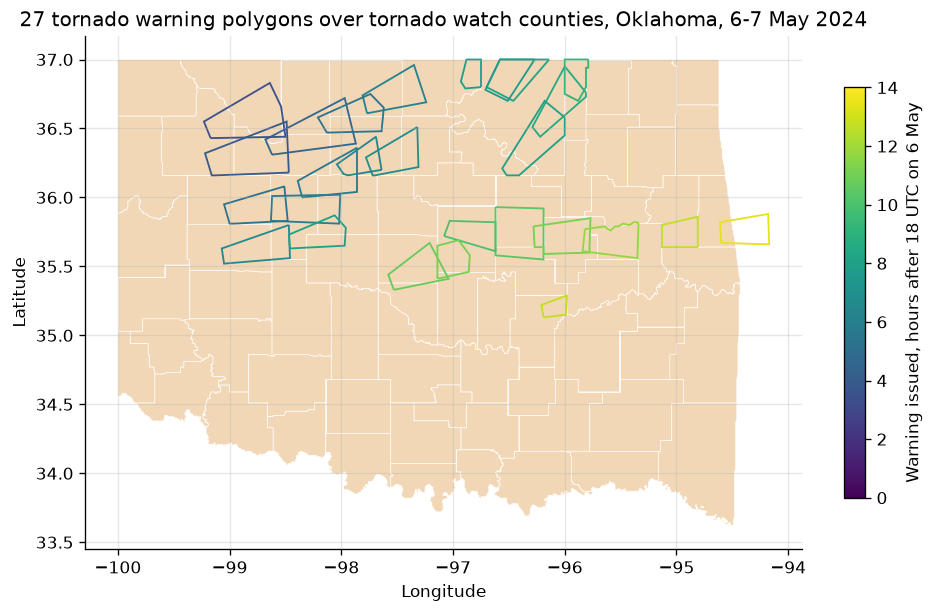

In [6]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
for shape in rows.loc[(rows["PHENOM"] == "TO") & (rows["SIG"] == "A"), "shape"]:
    if (county := patch(shape, facecolor="#f2d7b6", edgecolor="white", linewidth=0.4)) is not None:
        ax.add_patch(county)
polygons = rows[(rows["PHENOM"] == "TO") & (rows["SIG"] == "W") & (rows["GTYPE"] == "P")]
hours = (polygons["ISSUED"] - pd.Timestamp("2024-05-06T18:00Z")).dt.total_seconds() / 3600
norm = plt.Normalize(0, 14)
colors = plt.cm.viridis(norm(hours))
for shape, color in zip(polygons["shape"], colors, strict=True):
    ax.add_patch(patch(shape, facecolor="none", edgecolor=color, linewidth=1.1))
ax.autoscale_view()
ax.set_aspect(1 / 0.81)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
scale = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
bar = fig.colorbar(scale, ax=ax, shrink=0.8)
bar.set_label("Warning issued, hours after 18 UTC on 6 May")
ax.set_title(
    f"{len(polygons)} tornado warning polygons over tornado watch counties, Oklahoma, 6-7 May 2024"
)
plt.show()

Two tornado watches, 189 and 193, covered 74 of Oklahoma's 77 counties, and
the warnings moved east with the storms, from the northwest at 21:33 UTC to
the Arkansas line at 07:26 the next morning.

The window selects by `ISSUED`, the event's start as last updated, and
`INIT_ISS` is when the product that started it was sent. Usually they are the
same instant. They are not here for tornado watch 193: the offices' county
products for it went out at 03:13 and 03:14, a minute or two before the
watch's own start at 03:15. For a winter storm watch sent a day ahead of the
start it gives, the gap is a day. To keep only what was known before a
moment, filter on `INIT_ISS`.

In [7]:
late = rows[rows["ISSUED"] != rows["INIT_ISS"]]
print(f"Rows whose ISSUED differs from INIT_ISS: {len(late)} of {len(rows)}")
late.groupby(["PHENOM", "SIG", "ETN", "ISSUED", "INIT_ISS"]).size().rename("counties").to_frame()

Rows whose ISSUED differs from INIT_ISS: 22 of 167


counties
PHENOM SIG ETN ISSUED                    INIT_ISS                           
TO     A   193 2024-05-07 03:15:00+00:00 2024-05-07 03:13:00+00:00         7
                                         2024-05-07 03:14:00+00:00        15

## Pin and cite

`verify` checks the cached file against the lockfile's checksum; because the
zip is rewritten canonically, a later pull of the same window restores the same
bytes. Keep the manifest and lockfile with your analysis; the citation below is
what a methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nws-warnings
  National Weather Service watch, warning, and advisory products, as archived and served by the Iowa Environmental Mesonet of Iowa State University, accessed via usdata
  homepage: https://mesonet.agron.iastate.edu/request/gis/watchwarn.phtml
  license: Public domain (NWS products; IEM materials are public domain, attribution appreciated)
  terms: https://mesonet.agron.iastate.edu/disclaimer.php
  retrieved: 2026-10-08; 1 checksummed asset (326,270 bytes) pinned by usdata 0.34.0
  sources: oklahoma


## What was awkward

- There is no shapefile reader, so every notebook needs pyshp or geopandas
  and a helper like `read_zip` to get from the zip to a frame with times.
- The DBF truncates column names to ten characters (`TORNTAG`, `PROD_ID`),
  while the CSV in the same zip spells them out (`TORNADOTAG`,
  `PRODUCT_ID`), so code written against one does not run on the other.
- Timestamps are text with no timezone marker; they are UTC, which only the
  documentation says.
- The window selects by `ISSUED`, the event start as last updated, which is
  neither when the product was sent nor when the event was in effect. For
  "what was known before this moment", widen the window and filter on
  `INIT_ISS` yourself.
- Canonical zips are stored uncompressed, four to five times the size IEM
  sends, so a month of every product nationwide is large; narrow with
  `events`, a state, or `storm_based`.